## 환경 설정 및 뷰 생성

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mc
import numpy as np

sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', None)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
import duckdb

con = duckdb.connect()
con.execute("""
    CREATE OR REPLACE VIEW loans AS 
    SELECT * FROM read_csv_auto('accepted_cleaned_v1.csv')
""")
con.sql("SELECT COUNT(*) FROM loans").show() # 2,139,958 나오면 정상

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      2139958 │
└──────────────┘



## issue_year별 결과확정비율·부도율 확인 (train/test 경계 결정 근거)

In [4]:
r = con.execute("""
    WITH t AS (
        SELECT *, 
        CASE 
            WHEN loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off') THEN 1 
            WHEN loan_status IN ('Fully Paid', 'Does not meet the credit policy. Status:Fully Paid') THEN 0
        END AS target
        FROM loans
    )
    SELECT
        issue_year, 
        COUNT(*) AS cnt, 
        SUM(CASE WHEN target IS NOT NULL THEN 1 ELSE 0 END) AS n_solved, 
        ROUND(100.0 * SUM(CASE WHEN target IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS solved_ratio, 
        ROUND(100.0 * AVG(target), 2) AS default_ratio, 
        ROUND(AVG(int_rate), 2) AS avg_int_rate
    FROM t
    GROUP BY issue_year
    ORDER BY issue_year
""").df()
print(r.to_string(index=False))

 issue_year    cnt  n_solved  solved_ratio  default_ratio  avg_int_rate
       2007    603     603.0        100.00          26.20         11.83
       2008   2393    2393.0        100.00          20.73         12.06
       2009   5281    5281.0        100.00          13.69         12.44
       2010  12537   12537.0        100.00          14.01         11.99
       2011  21721   21721.0        100.00          15.18         12.22
       2012  53367   53367.0        100.00          16.20         13.64
       2013 134814  134804.0         99.99          15.60         14.53
       2014 235629  223103.0         94.68          18.45         13.77
       2015 420584  375145.0         89.20          20.18         12.60
       2016 425618  287819.0         67.62          23.26         13.02
       2017 401154  156290.0         38.96          22.79         13.18
       2018 426257   49230.0         11.55          15.17         12.60


In [5]:
# 1) 원본 CSV를 뷰로 연결
con.execute("""
    CREATE OR REPLACE VIEW loans AS
    SELECT * FROM read_csv_auto('accepted_cleaned_v1.csv')
""")

# 2) target 정의 + Current/Late 등 미확정 상태 제외
con.execute("""
    CREATE OR REPLACE VIEW loans_pd AS
    SELECT *,
        CASE
            WHEN loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off') THEN 1
            WHEN loan_status IN ('Fully Paid', 'Does not meet the credit policy. Status:Fully Paid') THEN 0
        END AS target
    FROM loans
    WHERE loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off',
                           'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid')
""")

# 3) early_era 플래그 추가
con.execute("""
    CREATE OR REPLACE VIEW loans_model AS
    SELECT *,
        CASE WHEN issue_year <= 2011 THEN 1 ELSE 0 END AS early_era
    FROM loans_pd
""")

# 4) 확인용 조회
check = con.sql("SELECT early_era, COUNT(*) AS n FROM loans_model GROUP BY early_era").df()
print(check)

   early_era        n
0          0  1279758
1          1    42535


In [6]:
con.execute("""
    CREATE OR REPLACE VIEW loans_model AS
    SELECT *,
        CASE WHEN issue_year <= 2011 THEN 1 ELSE 0 END AS early_era,

        CASE WHEN mths_since_last_delinq IS NULL THEN 0 ELSE 1 END AS had_delinq,
        COALESCE(mths_since_last_delinq, -1) AS mths_since_last_delinq_filled,
        CASE WHEN mths_since_last_record IS NULL THEN 0 ELSE 1 END AS had_record,
        COALESCE(mths_since_last_record, -1) AS mths_since_last_record_filled,
        CASE WHEN mths_since_last_major_derog IS NULL THEN 0 ELSE 1 END AS had_major_derog,
        COALESCE(mths_since_last_major_derog, -1) AS mths_since_last_major_derog_filled,
        CASE WHEN mths_since_recent_bc_dlq IS NULL THEN 0 ELSE 1 END AS had_bc_dlq,
        COALESCE(mths_since_recent_bc_dlq, -1) AS mths_since_recent_bc_dlq_filled,
        CASE WHEN mths_since_recent_revol_delinq IS NULL THEN 0 ELSE 1 END AS had_revol_delinq,
        COALESCE(mths_since_recent_revol_delinq, -1) AS mths_since_recent_revol_delinq_filled,
        CASE WHEN mths_since_recent_inq IS NULL THEN 0 ELSE 1 END AS had_recent_inq,
        COALESCE(mths_since_recent_inq, -1) AS mths_since_recent_inq_filled,

        COALESCE(avg_cur_bal, -1) AS avg_cur_bal_filled,
        COALESCE(tot_cur_bal, -1) AS tot_cur_bal_filled,
        COALESCE(tot_coll_amt, -1) AS tot_coll_amt_filled,
        COALESCE(num_il_tl, -1) AS num_il_tl_filled,
        COALESCE(num_op_rev_tl, -1) AS num_op_rev_tl_filled,
        COALESCE(num_rev_accts, -1) AS num_rev_accts_filled,
        COALESCE(num_rev_tl_bal_gt_0, -1) AS num_rev_tl_bal_gt_0_filled,
        COALESCE(num_actv_rev_tl, -1) AS num_actv_rev_tl_filled,
        COALESCE(num_bc_tl, -1) AS num_bc_tl_filled,
        COALESCE(num_tl_30dpd, -1) AS num_tl_30dpd_filled,
        COALESCE(num_tl_90g_dpd_24m, -1) AS num_tl_90g_dpd_24m_filled,
        COALESCE(num_tl_op_past_12m, -1) AS num_tl_op_past_12m_filled,
        COALESCE(mo_sin_old_rev_tl_op, -1) AS mo_sin_old_rev_tl_op_filled,
        COALESCE(mo_sin_rcnt_rev_tl_op, -1) AS mo_sin_rcnt_rev_tl_op_filled,
        COALESCE(mo_sin_rcnt_tl, -1) AS mo_sin_rcnt_tl_filled,
        COALESCE(tot_hi_cred_lim, -1) AS tot_hi_cred_lim_filled,
        COALESCE(total_il_high_credit_limit, -1) AS total_il_high_credit_limit_filled,
        COALESCE(num_accts_ever_120_pd, -1) AS num_accts_ever_120_pd_filled,
        COALESCE(num_actv_bc_tl, -1) AS num_actv_bc_tl_filled,
        COALESCE(total_rev_hi_lim, -1) AS total_rev_hi_lim_filled,
        COALESCE(pct_tl_nvr_dlq, -1) AS pct_tl_nvr_dlq_filled,
        -- 그룹B에 추가 편입: 3.78% 뭉치 4개
        COALESCE(acc_open_past_24mths, -1) AS acc_open_past_24mths_filled,
        COALESCE(total_bc_limit, -1) AS total_bc_limit_filled,
        COALESCE(mort_acc, -1) AS mort_acc_filled,
        COALESCE(total_bal_ex_mort, -1) AS total_bal_ex_mort_filled, 
        -- 새로 발견한 그룹B 편입 6개 (2013 컷오프, 잔여결측 미미)
        COALESCE(num_sats, -1) AS num_sats_filled,
        COALESCE(num_bc_sats, -1) AS num_bc_sats_filled,
        COALESCE(bc_util, -1) AS bc_util_filled,
        COALESCE(percent_bc_gt_75, -1) AS percent_bc_gt_75_filled,
        COALESCE(bc_open_to_buy, -1) AS bc_open_to_buy_filled,
        COALESCE(mths_since_recent_bc, -1) AS mths_since_recent_bc_filled,

        -- 그룹B': 2013년 컷오프 + 잔여 이력없음 혼합형, 전용 플래그 추가
        CASE WHEN mo_sin_old_il_acct IS NULL THEN 0 ELSE 1 END AS had_il_acct,
        COALESCE(mo_sin_old_il_acct, -1) AS mo_sin_old_il_acct_filled,
        CASE WHEN num_tl_120dpd_2m IS NULL THEN 0 ELSE 1 END AS had_120dpd_2m_data,
        COALESCE(num_tl_120dpd_2m, -1) AS num_tl_120dpd_2m_filled, 
            
        CASE WHEN mort_acc >= 1 THEN 1 ELSE 0 END AS mort_acc_has, 
            
        -- emp_length: 결측을 별도 카테고리로
        COALESCE(emp_length, 'Unknown') AS emp_length_filled,

        -- avg_cur_bal hinge (knot1=1633, knot2=7317)
        GREATEST(0, avg_cur_bal_filled - 1633) AS hinge1_avg_cur_bal,
        GREATEST(0, avg_cur_bal_filled - 7317) AS hinge2_avg_cur_bal, 

        -- 미미한 결측 5개: 카운트류는 0, 비율(revol_util)은 중앙값
        COALESCE(pub_rec_bankruptcies, 0) AS pub_rec_bankruptcies_filled,
        COALESCE(tax_liens, 0) AS tax_liens_filled,
        COALESCE(collections_12_mths_ex_med, 0) AS collections_12_mths_ex_med_filled,
        COALESCE(chargeoff_within_12_mths, 0) AS chargeoff_within_12_mths_filled,
        COALESCE(revol_util, MEDIAN(revol_util) OVER ()) AS revol_util_filled, 
        -- 뒤늦게 발견한 미미한 결측 4개 (2007년 초기 29건 + annual_inc 4건)
        COALESCE(inq_last_6mths, 0) AS inq_last_6mths_filled,
        COALESCE(delinq_2yrs, 0) AS delinq_2yrs_filled,
        COALESCE(pub_rec, 0) AS pub_rec_filled,
        COALESCE(annual_inc, MEDIAN(annual_inc) OVER ()) AS annual_inc_filled, 
        
        -- earliest_cr_line → 신용거래 시작 후 대출일까지 개월수로 변환
        COALESCE(DATE_DIFF('month', STRPTIME(earliest_cr_line, '%b-%Y'), STRPTIME(issue_d, '%b-%Y')), -1) AS credit_history_months
    
        FROM loans_pd
""")

## 모델링 시작

## loans_model에서 데이터 추출

In [7]:
final_cols = ['id','issue_year','target','acc_now_delinq','acc_open_past_24mths_filled','annual_inc_filled',
    'avg_cur_bal_filled','bc_open_to_buy_filled','bc_util_filled','chargeoff_within_12_mths_filled',
    'collections_12_mths_ex_med_filled','credit_history_months','delinq_2yrs_filled','delinq_amnt','dti',
    'early_era','emp_length_filled','fico_range_high','fico_range_low','had_120dpd_2m_data','had_bc_dlq',
    'had_delinq','had_il_acct','had_major_derog','had_recent_inq','had_record','had_revol_delinq',
    'hinge1_avg_cur_bal','hinge2_avg_cur_bal','home_ownership','inq_last_6mths_filled','loan_amnt',
    'mo_sin_old_il_acct_filled','mo_sin_old_rev_tl_op_filled','mo_sin_rcnt_rev_tl_op_filled',
    'mo_sin_rcnt_tl_filled','mort_acc_filled','mort_acc_has','mths_since_last_delinq_filled',
    'mths_since_last_major_derog_filled','mths_since_last_record_filled','mths_since_recent_bc_dlq_filled',
    'mths_since_recent_bc_filled','mths_since_recent_inq_filled','mths_since_recent_revol_delinq_filled',
    'num_accts_ever_120_pd_filled','num_actv_bc_tl_filled','num_actv_rev_tl_filled','num_bc_sats_filled',
    'num_bc_tl_filled','num_il_tl_filled','num_op_rev_tl_filled','num_rev_accts_filled',
    'num_rev_tl_bal_gt_0_filled','num_sats_filled','num_tl_120dpd_2m_filled','num_tl_30dpd_filled',
    'num_tl_90g_dpd_24m_filled','num_tl_op_past_12m_filled','open_acc','pct_tl_nvr_dlq_filled',
    'percent_bc_gt_75_filled','pub_rec_filled','pub_rec_bankruptcies_filled','purpose','revol_bal',
    'revol_util_filled','sub_grade','tax_liens_filled','term','tot_coll_amt_filled','tot_cur_bal_filled',
    'tot_hi_cred_lim_filled','total_acc','total_bal_ex_mort_filled','total_bc_limit_filled',
    'total_il_high_credit_limit_filled','total_rev_hi_lim_filled','verification_status']

cols_str = ', '.join(final_cols)

df = con.sql(f"""
    SELECT {cols_str}
    FROM loans_model
    WHERE issue_year BETWEEN 2007 AND 2016
""").df()

print(df.shape)
print(df['issue_year'].value_counts().sort_index())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(1116773, 79)
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375145
2016    287819
Name: count, dtype: int64


## train/test 분할

In [8]:
train = df[df['issue_year'] <= 2014].copy()
test_2015 = df[df['issue_year'] == 2015].copy()
test_2016 = df[df['issue_year'] == 2016].copy()

print('train:', train.shape, '| target 비율:', train['target'].mean().round(4))
print('test_2015:', test_2015.shape, '| target 비율:', test_2015['target'].mean().round(4))
print('test_2016:', test_2016.shape, '| target 비율:', test_2016['target'].mean().round(4))

train: (453809, 79) | target 비율: 0.1703
test_2015: (375145, 79) | target 비율: 0.2018
test_2016: (287819, 79) | target 비율: 0.2326


## 최종 Feature 리스트 정의 (다중공선성 그룹 반영)

In [9]:
# 다중공선성 8그룹 대표(로지스틱용)
group_repr_logistic = ['delinq_2yrs_filled', 'acc_open_past_24mths_filled', 'bc_open_to_buy_filled',
                        'mo_sin_rcnt_tl_filled', 'mths_since_recent_inq_filled', 'had_recent_inq',
                        'pub_rec_filled', 'fico_range_low']

# 다중공선성 8그룹 전체(트리용)
group_full_tree = ['delinq_2yrs_filled','delinq_amnt','acc_now_delinq','num_tl_30dpd_filled','num_tl_90g_dpd_24m_filled',
    'num_tl_120dpd_2m_filled','had_120dpd_2m_data','num_accts_ever_120_pd_filled','chargeoff_within_12_mths_filled',
    'open_acc','total_acc','num_sats_filled','num_bc_sats_filled','num_actv_bc_tl_filled','num_actv_rev_tl_filled',
    'num_bc_tl_filled','num_il_tl_filled','num_op_rev_tl_filled','num_rev_accts_filled','num_rev_tl_bal_gt_0_filled',
    'acc_open_past_24mths_filled','num_tl_op_past_12m_filled',
    'revol_bal','revol_util_filled','bc_open_to_buy_filled','bc_util_filled','total_bc_limit_filled',
    'total_rev_hi_lim_filled','percent_bc_gt_75_filled',
    'tot_cur_bal_filled','total_bal_ex_mort_filled','tot_hi_cred_lim_filled','total_il_high_credit_limit_filled',
    'mo_sin_old_il_acct_filled','had_il_acct','mo_sin_old_rev_tl_op_filled','mo_sin_rcnt_rev_tl_op_filled','mo_sin_rcnt_tl_filled',
    'mths_since_recent_bc_filled','mths_since_recent_inq_filled','had_recent_inq',
    'pub_rec_filled','pub_rec_bankruptcies_filled','mths_since_last_record_filled','had_record','tax_liens_filled',
    'fico_range_low','fico_range_high']

# 공통(그룹 무관, 4개 조합 다 들어감)
common = ['annual_inc_filled','dti','inq_last_6mths_filled','loan_amnt','early_era','credit_history_months',
          'collections_12_mths_ex_med_filled','tot_coll_amt_filled','pct_tl_nvr_dlq_filled',
          'mths_since_last_delinq_filled','had_delinq',
          'mths_since_last_major_derog_filled','had_major_derog',
          'mths_since_recent_bc_dlq_filled','had_bc_dlq',
          'mths_since_recent_revol_delinq_filled','had_revol_delinq',
          'home_ownership','purpose','verification_status','term','emp_length_filled']

# 로지스틱: mort_acc_has + avg_cur_bal 3항
logistic_special = ['mort_acc_has','avg_cur_bal_filled','hinge1_avg_cur_bal','hinge2_avg_cur_bal']
# 트리: mort_acc_filled + avg_cur_bal 1항
tree_special = ['mort_acc_filled','avg_cur_bal_filled']

logistic_features_B = common + group_repr_logistic + logistic_special
tree_features_B = common + group_full_tree + tree_special
logistic_features_A = logistic_features_B + ['sub_grade']
tree_features_A = tree_features_B + ['sub_grade']

print('logistic_B:', len(logistic_features_B))
print('tree_B:', len(tree_features_B))
print('logistic_A:', len(logistic_features_A))
print('tree_A:', len(tree_features_A))

logistic_B: 34
tree_B: 72
logistic_A: 35
tree_A: 73


## 범주형 인코딩 공통 설정

In [10]:
categorical_cols = ['home_ownership', 'purpose', 'verification_status', 'term', 'emp_length_filled']

X_train_B = pd.get_dummies(train[logistic_features_B], columns=categorical_cols, drop_first=True)
y_train_B = train['target']

X_test_2015_B = pd.get_dummies(test_2015[logistic_features_B], columns=categorical_cols, drop_first=True)
X_test_2015_B = X_test_2015_B.reindex(columns=X_train_B.columns, fill_value=0)

print(X_train_B.shape)
print(X_test_2015_B.shape)

(453809, 61)
(375145, 61)


## 로지스틱회귀 학습 — Model A/B

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

def calc_ks(y_true, y_pred):
    good = y_pred[y_true == 0]
    bad = y_pred[y_true == 1]
    return ks_2samp(good, bad).statistic

scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_2015_B_scaled = scaler_B.transform(X_test_2015_B)

model_logistic_B = LogisticRegression(max_iter=1000)
model_logistic_B.fit(X_train_B_scaled, y_train_B)

pred_train_B = model_logistic_B.predict_proba(X_train_B_scaled)[:, 1]
pred_test_2015_B = model_logistic_B.predict_proba(X_test_2015_B_scaled)[:, 1]

auc_train_B = roc_auc_score(y_train_B, pred_train_B)
auc_test_2015_B = roc_auc_score(test_2015['target'], pred_test_2015_B)
ks_train_B = calc_ks(y_train_B.values, pred_train_B)
ks_test_2015_B = calc_ks(test_2015['target'].values, pred_test_2015_B)

print('=== Model B (등급 제외) ===')
print('train AUC:', round(auc_train_B, 4), '| test_2015 AUC:', round(auc_test_2015_B, 4))
print('train KS:', round(ks_train_B, 4), '| test_2015 KS:', round(ks_test_2015_B, 4))

=== Model B (등급 제외) ===
train AUC: 0.6953 | test_2015 AUC: 0.7201
train KS: 0.2826 | test_2015 KS: 0.3209


In [12]:
X_train_A = pd.get_dummies(train[logistic_features_A], columns=categorical_cols + ['sub_grade'], drop_first=True)
y_train_A = train['target']

X_test_2015_A = pd.get_dummies(test_2015[logistic_features_A], columns=categorical_cols + ['sub_grade'], drop_first=True)
X_test_2015_A = X_test_2015_A.reindex(columns=X_train_A.columns, fill_value=0)

scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_2015_A_scaled = scaler_A.transform(X_test_2015_A)

model_logistic_A = LogisticRegression(max_iter=1000)
model_logistic_A.fit(X_train_A_scaled, y_train_A)

pred_train_A = model_logistic_A.predict_proba(X_train_A_scaled)[:, 1]
pred_test_2015_A = model_logistic_A.predict_proba(X_test_2015_A_scaled)[:, 1]

auc_train_A = roc_auc_score(y_train_A, pred_train_A)
auc_test_2015_A = roc_auc_score(test_2015['target'], pred_test_2015_A)
ks_train_A = calc_ks(y_train_A.values, pred_train_A)
ks_test_2015_A = calc_ks(test_2015['target'].values, pred_test_2015_A)

print('=== Model A (등급 포함) ===')
print('train AUC:', round(auc_train_A, 4), '| test_2015 AUC:', round(auc_test_2015_A, 4))
print('train KS:', round(ks_train_A, 4), '| test_2015 KS:', round(ks_test_2015_A, 4))
print()
print('=== Model B (등급 제외, 참고용 재출력) ===')
print('train AUC:', round(auc_train_B, 4), '| test_2015 AUC:', round(auc_test_2015_B, 4))
print('train KS:', round(ks_train_B, 4), '| test_2015 KS:', round(ks_test_2015_B, 4))

=== Model A (등급 포함) ===
train AUC: 0.7044 | test_2015 AUC: 0.7344
train KS: 0.2975 | test_2015 KS: 0.3419

=== Model B (등급 제외, 참고용 재출력) ===
train AUC: 0.6953 | test_2015 AUC: 0.7201
train KS: 0.2826 | test_2015 KS: 0.3209


In [13]:
!pip install lightgbm

## 트리모델(LightGBM) 학습 — Model A/B

In [14]:
import lightgbm as lgb

X_train_tree_B = train[tree_features_B].copy()
X_test_2015_tree_B = test_2015[tree_features_B].copy()

for col in categorical_cols:  # home_ownership, purpose, verification_status, term, emp_length_filled
    X_train_tree_B[col] = X_train_tree_B[col].astype('category')
    X_test_2015_tree_B[col] = X_test_2015_tree_B[col].astype('category')

y_train_tree_B = train['target']

model_tree_B = lgb.LGBMClassifier(random_state=42)
model_tree_B.fit(X_train_tree_B, y_train_tree_B, categorical_feature=categorical_cols)

pred_train_tree_B = model_tree_B.predict_proba(X_train_tree_B)[:, 1]
pred_test_2015_tree_B = model_tree_B.predict_proba(X_test_2015_tree_B)[:, 1]

auc_train_tree_B = roc_auc_score(y_train_tree_B, pred_train_tree_B)
auc_test_2015_tree_B = roc_auc_score(test_2015['target'], pred_test_2015_tree_B)
ks_train_tree_B = calc_ks(y_train_tree_B.values, pred_train_tree_B)
ks_test_2015_tree_B = calc_ks(test_2015['target'].values, pred_test_2015_tree_B)

print('\n=== Tree Model B (등급 제외) ===')
print('train AUC:', round(auc_train_tree_B, 4), '| test_2015 AUC:', round(auc_test_2015_tree_B, 4))
print('train KS:', round(ks_train_tree_B, 4), '| test_2015 KS:', round(ks_test_2015_tree_B, 4))

[LightGBM] [Info] Number of positive: 77261, number of negative: 376548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030006 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7115
[LightGBM] [Info] Number of data points in the train set: 453809, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.170250 -> initscore=-1.583856
[LightGBM] [Info] Start training from score -1.583856

=== Tree Model B (등급 제외) ===
train AUC: 0.7287 | test_2015 AUC: 0.7339
train KS: 0.3329 | test_2015 KS: 0.3402


In [15]:
tree_categorical_cols = categorical_cols + ['sub_grade']

X_train_tree_A = train[tree_features_A].copy()
X_test_2015_tree_A = test_2015[tree_features_A].copy()

for col in tree_categorical_cols:
    X_train_tree_A[col] = X_train_tree_A[col].astype('category')
    X_test_2015_tree_A[col] = X_test_2015_tree_A[col].astype('category')

y_train_tree_A = train['target']

model_tree_A = lgb.LGBMClassifier(random_state=42)
model_tree_A.fit(X_train_tree_A, y_train_tree_A, categorical_feature=tree_categorical_cols)

pred_train_tree_A = model_tree_A.predict_proba(X_train_tree_A)[:, 1]
pred_test_2015_tree_A = model_tree_A.predict_proba(X_test_2015_tree_A)[:, 1]

auc_train_tree_A = roc_auc_score(y_train_tree_A, pred_train_tree_A)
auc_test_2015_tree_A = roc_auc_score(test_2015['target'], pred_test_2015_tree_A)
ks_train_tree_A = calc_ks(y_train_tree_A.values, pred_train_tree_A)
ks_test_2015_tree_A = calc_ks(test_2015['target'].values, pred_test_2015_tree_A)

print('\n=== Tree Model A (등급 포함) ===')
print('train AUC:', round(auc_train_tree_A, 4), '| test_2015 AUC:', round(auc_test_2015_tree_A, 4))
print('train KS:', round(ks_train_tree_A, 4), '| test_2015 KS:', round(ks_test_2015_tree_A, 4))

[LightGBM] [Info] Number of positive: 77261, number of negative: 376548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7150
[LightGBM] [Info] Number of data points in the train set: 453809, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.170250 -> initscore=-1.583856
[LightGBM] [Info] Start training from score -1.583856

=== Tree Model A (등급 포함) ===
train AUC: 0.7319 | test_2015 AUC: 0.7402
train KS: 0.3391 | test_2015 KS: 0.3511


## test_2016(보조) 검증

In [16]:
# 로지스틱 B
X_test_2016_B = pd.get_dummies(test_2016[logistic_features_B], columns=categorical_cols, drop_first=True)
X_test_2016_B = X_test_2016_B.reindex(columns=X_train_B.columns, fill_value=0)
X_test_2016_B_scaled = scaler_B.transform(X_test_2016_B)
pred_test_2016_B = model_logistic_B.predict_proba(X_test_2016_B_scaled)[:, 1]

# 로지스틱 A
X_test_2016_A = pd.get_dummies(test_2016[logistic_features_A], columns=categorical_cols + ['sub_grade'], drop_first=True)
X_test_2016_A = X_test_2016_A.reindex(columns=X_train_A.columns, fill_value=0)
X_test_2016_A_scaled = scaler_A.transform(X_test_2016_A)
pred_test_2016_A = model_logistic_A.predict_proba(X_test_2016_A_scaled)[:, 1]

# 트리 B
X_test_2016_tree_B = test_2016[tree_features_B].copy()
for col in categorical_cols:
    X_test_2016_tree_B[col] = X_test_2016_tree_B[col].astype('category')
pred_test_2016_tree_B = model_tree_B.predict_proba(X_test_2016_tree_B)[:, 1]

# 트리 A
X_test_2016_tree_A = test_2016[tree_features_A].copy()
for col in tree_categorical_cols:
    X_test_2016_tree_A[col] = X_test_2016_tree_A[col].astype('category')
pred_test_2016_tree_A = model_tree_A.predict_proba(X_test_2016_tree_A)[:, 1]

# 4개 다 AUC/KS
results_2016 = {
    '로지스틱 B': (pred_test_2016_B,),
    '로지스틱 A': (pred_test_2016_A,),
    '트리 B': (pred_test_2016_tree_B,),
    '트리 A': (pred_test_2016_tree_A,),
}
y_2016 = test_2016['target']
for name, (pred,) in results_2016.items():
    auc = roc_auc_score(y_2016, pred)
    ks = calc_ks(y_2016.values, pred)
    print(f'{name}: AUC={auc:.4f}, KS={ks:.4f}')

로지스틱 B: AUC=0.6958, KS=0.2804
로지스틱 A: AUC=0.7116, KS=0.3071
트리 B: AUC=0.7112, KS=0.3023
트리 A: AUC=0.7189, KS=0.3162


## Calibration (확률 보정) 확인

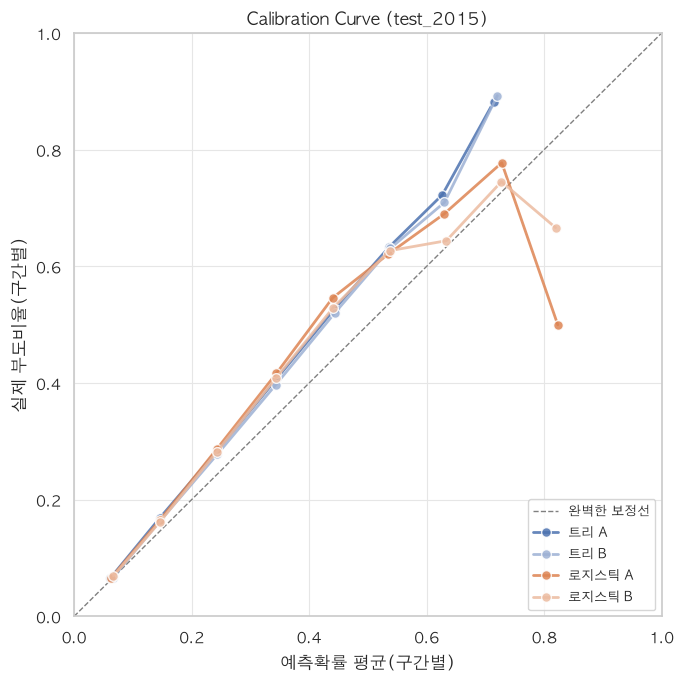

In [ ]:
def lighten(color, amount=0.45):
    c = np.array(mc.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)

deep = sns.color_palette("deep")
blue_dark, orange_dark = deep[0], deep[1]
blue_light, orange_light = lighten(blue_dark), lighten(orange_dark)

models_2015 = {
    '트리 A': (test_2015['target'], pred_test_2015_tree_A),
    '트리 B': (test_2015['target'], pred_test_2015_tree_B),
    '로지스틱 A': (test_2015['target'], pred_test_2015_A),
    '로지스틱 B': (test_2015['target'], pred_test_2015_B),
}

palette = {
    '트리 A': blue_dark,
    '트리 B': blue_light,
    '로지스틱 A': orange_dark,
    '로지스틱 B': orange_light,
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='완벽한 보정선')

for name, (y_true, y_pred) in models_2015.items():
    frac_pos, mean_pred = calibration_curve(y_true, y_pred, n_bins=10)
    ax.plot(
        mean_pred, frac_pos,
        marker='o', markersize=7, markeredgecolor='white',
        color=palette[name], alpha=0.85, linewidth=2,
        label=name
    )

ax.grid(color='#e6e6e6', linewidth=0.8)
ax.set_xlabel('예측확률 평균(구간별)')
ax.set_ylabel('실제 부도비율(구간별)')
ax.set_title('Calibration Curve (test_2015)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right", fontsize=9, frameon=True)
plt.tight_layout()
# plt.savefig('images/6-2_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.metrics import brier_score_loss

brier_scores = {}
for name, (y_true, y_pred) in models_2015.items():
    brier_scores[name] = brier_score_loss(y_true, y_pred)

for name, score in brier_scores.items():
    print(f'{name}: Brier score = {score:.5f}')

로지스틱 B: Brier score = 0.14500
로지스틱 A: Brier score = 0.14343
트리 B: Brier score = 0.14269
트리 A: Brier score = 0.14216


In [19]:
# 4개 모델 최종 종합
summary = pd.DataFrame([
    {'model': '로지스틱 B', 'auc_2015': auc_test_2015_B, 'ks_2015': ks_test_2015_B,
     'auc_2016': roc_auc_score(y_2016, pred_test_2016_B), 'ks_2016': calc_ks(y_2016.values, pred_test_2016_B),
     'brier_2015': brier_scores['로지스틱 B']},
    {'model': '로지스틱 A', 'auc_2015': auc_test_2015_A, 'ks_2015': ks_test_2015_A,
     'auc_2016': roc_auc_score(y_2016, pred_test_2016_A), 'ks_2016': calc_ks(y_2016.values, pred_test_2016_A),
     'brier_2015': brier_scores['로지스틱 A']},
    {'model': '트리 B', 'auc_2015': auc_test_2015_tree_B, 'ks_2015': ks_test_2015_tree_B,
     'auc_2016': roc_auc_score(y_2016, pred_test_2016_tree_B), 'ks_2016': calc_ks(y_2016.values, pred_test_2016_tree_B),
     'brier_2015': brier_scores['트리 B']},
    {'model': '트리 A', 'auc_2015': auc_test_2015_tree_A, 'ks_2015': ks_test_2015_tree_A,
     'auc_2016': roc_auc_score(y_2016, pred_test_2016_tree_A), 'ks_2016': calc_ks(y_2016.values, pred_test_2016_tree_A),
     'brier_2015': brier_scores['트리 A']},
]).round(4)
summary


,model,auc_2015,ks_2015,auc_2016,ks_2016,brier_2015
0,로지스틱 B,0.7201,0.3209,0.6958,0.2804,0.1450
1,로지스틱 A,0.7344,0.3419,0.7116,0.3071,0.1434
2,트리 B,0.7339,0.3402,0.7112,0.3023,0.1427
3,트리 A,0.7402,0.3511,0.7189,0.3162,0.1422


---

In [20]:
export_df = pd.DataFrame({
    'id': test_2015['id'].values,
    'target': test_2015['target'].values,
    'pd_pred': pred_test_2015_tree_A
})
export_df.to_csv('test_2015_pd_predictions.csv', index=False)
print(export_df.shape)
export_df.head()

(375145, 3)


,id,target,pd_pred
0,68407277,0,0.117073
1,68355089,0,0.246858
2,68476807,0,0.270052
3,68426831,0,0.198688
4,68476668,0,0.065894


In [21]:
export_df_2016 = pd.DataFrame({
    'id': test_2016['id'].values,
    'target': test_2016['target'].values,
    'pd_pred': pred_test_2016_tree_A
})
export_df_2016.to_csv('test_2016_pd_predictions.csv', index=False)
print(export_df_2016.shape)

(287819, 3)


In [22]:
export_df_logistic_A = pd.DataFrame({
    'id': test_2015['id'].values,
    'target': test_2015['target'].values,
    'pd_pred': pred_test_2015_A
})
export_df_logistic_A.to_csv('test_2015_pd_predictions_logisticA.csv', index=False)
print(export_df_logistic_A.shape)

(375145, 3)
